# Estudo prático sobre Redes Neurais Recorrentes

## Objetivo
Geração de texto autoregressivo

## Tipo de tokenização
Subword-level (BPE)

## Dataset
Wikipedia (no-pic-pt)

## Idioma
Português

## Tamanho das observações
Parágrafos entre 150 e 200 caracteres.

## Arquitetura utilizada
LSTM (Long Short-term Memory)

In [1]:
import torch
import torch.nn as nn
from tokenizers import Tokenizer
from typing import List, Tuple
import pandas as pd
from lstm import LSTM, LSTMBidirectional, LSTMAttention
import json
from tqdm import tqdm
from utils import Dataset
from inference import test_step, evaluate_models, predicting, test_step_attention
import os
from pprint import pprint

In [2]:
models_retry = [LSTM, LSTMBidirectional, LSTMAttention]

In [3]:
model_names = os.listdir('runs/')
modelos = {}
configs = {}
for model_name in model_names:
    with open(f"models/{model_name}/config.json", "r", encoding="utf-8") as f:
        config: dict = json.load(f)
    for M in models_retry:
        try:
            model = M(
                config['emb_size'],
                config['vocab_size'],
                config['encoder_num_layers'],
                config['encoder_hidden_size'],
                config['encoder_dropout'],
                config['decoder_num_layers'],
                config['decoder_hidden_size'],
                config['decoder_dropout']
            ).to('cpu')
            model.load_state_dict(torch.load(f"models/{model_name}/model.pt", map_location='cpu'))
            break
        except Exception as e:
            continue
    

    tokenizer = Tokenizer.from_file(f"artifacts/bpe_{config['vocab_size']}.json")
    
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    config['parameters'] = trainable_params
    config.pop('device')
    config.pop('exp_name')
    modelos[model_name] = (model, tokenizer)
    configs[model_name] = config

1536 768
1536 768
1024 512
3072 1536
4096 2048


## Hiperpârametros de treinamento
Foram feitos 4 tokenizadores de tamanhos diversos de vocabulário (5k, 10k, 25k e 50k).
O Learning rate foi feito sem nenhum tipo de scheduler, fixado em 1e-4.

In [4]:
df = pd.DataFrame.from_dict(configs).T
df

,vocab_size,max_len,emb_size,encoder_hidden_size,encoder_num_layers,encoder_dropout,decoder_hidden_size,decoder_num_layers,decoder_dropout,batch_size,eval_batch_size,accum_steps,log_steps,eval_steps,learning_rate,epochs,parameters,warmup_steps
v1,25000.0,512.0,128.0,256.0,2.0,0.0,256.0,2.0,0.0,32.0,64.0,1.0,500.0,2000.0,0.0001,1000.0,11468200.0,NaN
v2,25000.0,512.0,256.0,384.0,2.0,0.0,384.0,2.0,0.0,32.0,64.0,1.0,500.0,2000.0,0.0001,1000.0,20362664.0,NaN
v3_bidirectional,25000.0,512.0,256.0,384.0,2.0,0.0,384.0,2.0,0.0,32.0,32.0,1.0,500.0,2000.0,0.0001,1000.0,26071976.0,NaN
v4_bidirectional_warmup,25000.0,512.0,256.0,384.0,2.0,0.0,384.0,2.0,0.0,32.0,64.0,1.0,500.0,2000.0,0.0001,1000.0,26071976.0,2000.0
v5_attention,25000.0,512.0,128.0,256.0,2.0,0.0,256.0,2.0,0.0,64.0,64.0,1.0,500.0,2000.0,0.0001,1000.0,20757160.0,2000.0
v6_attention_decoder_too,25000.0,512.0,256.0,768.0,2.0,0.0,768.0,2.0,0.0,16.0,16.0,2.0,500.0,2000.0,0.0001,1000.0,86153384.0,2000.0
v7_bidirectional_warmup,25000.0,512.0,256.0,1024.0,2.0,0.0,1024.0,2.0,0.0,64.0,64.0,1.0,500.0,2000.0,0.0001,1000.0,98138536.0,2000.0


### Curva de treino e validação

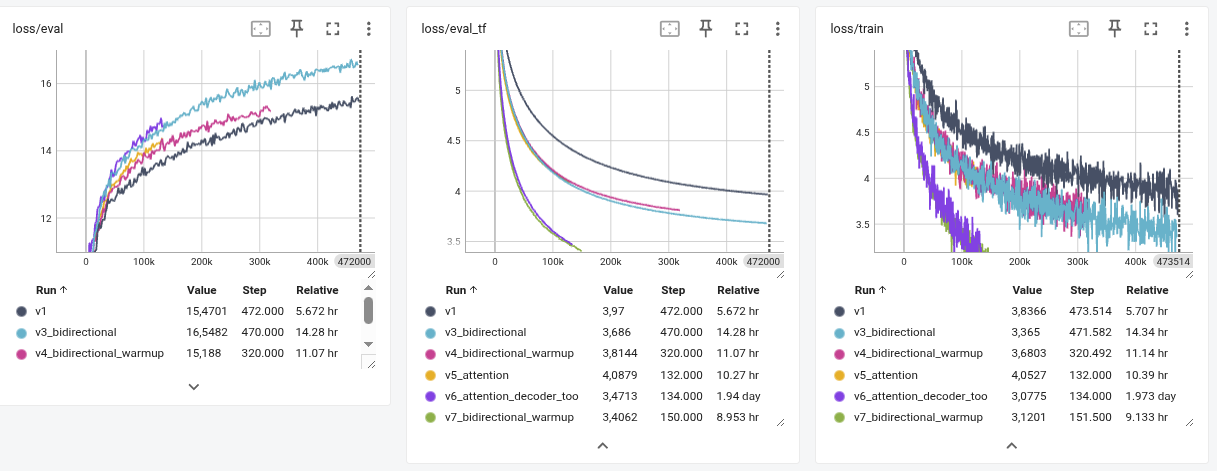

## 📈 Avaliação dos Gradientes

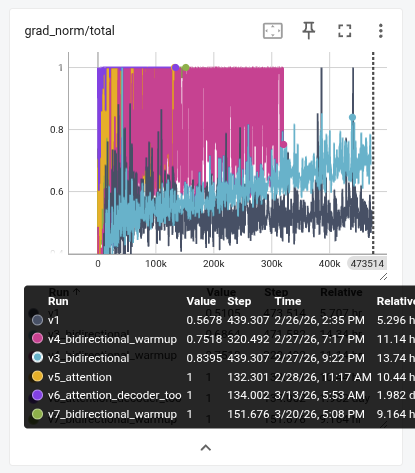

In [5]:
config_test = {
    'batch_size': 96,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'vocab_size': 25000
}

step_info = {'test_accum_steps': 0, 'test_loss_sum':0, 'test_loss_tf_sum': 0}

In [6]:
df_test = pd.read_parquet('data/test_wiki_cleaned_cutted.pq')

In [7]:
df_test_sample = df_test.sample(4096)

In [8]:
dict_function_test = {
    'v1': test_step,
    'v2': test_step,
    'v3_bidirectional': test_step,
    'v4_bidirectional_warmup': test_step,
    'v5_attention': test_step_attention,
    'v6_attention_decoder_too': test_step_attention,
    'v7_bidirectional_warmup': test_step
    }

In [ ]:
# modelo, tok = modelos['v5_attention']

# modelo = modelo.to(config_test['device'])

# dataset_test = Dataset(
#     df_test_sample.tokens.values.tolist(),
#     max_len=512
# )

# dataloader_test = torch.utils.data.DataLoader(
#     dataset=dataset_test, 
#     batch_size=config_test['batch_size'],
#     shuffle=True
# )



# loss, loss_tf, phrases_pred, phrases_input, tokens_pred_total, tokens_input_total, phrases_output, tokens_output_total = test_step_attention(config_test, step_info, modelo, dataloader_test, tok.get_vocab_size(), tok)
# df_results = pd.concat([df_results,pd.DataFrame({
#     'modelo': [model_name]*len(phrases_input), 
#     'frase_input_original': phrases_input, 
#     'frase_output_original': phrases_output,
#     'frase_preditada': phrases_pred,
#     'tokens_input_originais': tokens_input_total,
#     'tokens_output_originais': tokens_output_total,
#     'tokens_preditados': tokens_pred_total,
#     'loss': [loss]*len(phrases_input),
#     'loss_tf': [loss_tf]*len(phrases_input),
#     })])

In [10]:
# modelos.pop('v5_attention')

In [13]:
df_results = pd.DataFrame()

In [14]:
for model_name, item in modelos.items():
    modelo, tok = item
    print(model_name)

    modelo = modelo.to(config_test['device'])

    dataset_test = Dataset(
        df_test_sample.tokens.values.tolist(),
        max_len=512
    )

    dataloader_test = torch.utils.data.DataLoader(
        dataset=dataset_test, 
        batch_size=config_test['batch_size'],
        shuffle=True
    )

    function_step = dict_function_test[model_name]

    loss, loss_tf, phrases_pred, phrases_input, tokens_pred_total, tokens_input_total, phrases_output, tokens_output_total = function_step(config_test, step_info, modelo, dataloader_test, tok.get_vocab_size(), tok)
    df_results = pd.concat([df_results,pd.DataFrame({
        'modelo': [model_name]*len(phrases_input), 
        'frase_input_original': phrases_input, 
        'frase_output_original': phrases_output,
        'frase_preditada': phrases_pred,
        'tokens_input_originais': tokens_input_total,
        'tokens_output_originais': tokens_output_total,
        'tokens_preditados': tokens_pred_total,
        'loss': [loss]*len(phrases_input),
        'loss_tf': [loss_tf]*len(phrases_input),
        })])

v1


Testing: 100%|██████████| 43/43 [00:05<00:00,  7.48it/s]


v2


Testing: 100%|██████████| 43/43 [00:05<00:00,  7.52it/s]


v3_bidirectional


...

Testing: 100%|██████████| 43/43 [00:08<00:00,  4.83it/s]


v6_attention_decoder_too


Testing: 100%|██████████| 43/43 [00:20<00:00,  2.10it/s]


v7_bidirectional_warmup


Testing: 100%|██████████| 43/43 [00:13<00:00,  3.19it/s]


In [15]:
df_results = df_results.reset_index(drop=True)

In [16]:
df_results

,modelo,frase_input_original,frase_output_original,frase_preditada,tokens_input_originais,tokens_output_originais,tokens_preditados,loss,loss_tf
0,v1,A caverna de Nicanor n aɪ k eɪ n ər; grego: n...,"John Dickson, cuja filha Gladys Dickson, arqu...","ston, que foi o primeiro a ser construído em u...","[1, 198, 18250, 160, 4038, 218, 170, 180, 159,...","[2098, 12940, 718, 6, 3676, 2388, 5419, 171, 2...","[6868, 6, 210, 284, 176, 690, 159, 370, 4207, ...",15.452148,7.889386
1,v1,"Shelina Begum em bengali:; Rochdale, 27 de de...","ham. Em outubro de 2005, ela foi enviada em um...",", e em seguida, foi nomeado para o cargo de di...","[1, 16751, 387, 1604, 19350, 201, 6922, 1362, ...","[572, 8, 2, 1, 355, 1348, 160, 2272, 6, 846, 2...","[6, 158, 201, 3040, 6, 284, 2900, 243, 176, 25...",15.452148,7.889386
2,v1,Oratorio del Gonfalone ou Oratório de Gonfalo...,". Depois da unificação da Itália, em 1870, as ...",A igreja foi construída em 17 de agosto de 17...,"[1, 18959, 631, 271, 2245, 4557, 7838, 1792, 3...","[8, 2, 1, 1852, 208, 15629, 208, 2496, 6, 201,...","[2, 1, 198, 2777, 284, 4727, 201, 936, 160, 14...",15.452148,7.889386
3,v1,A franquia Pokémon gira em torno de 1025 espé...,divisão englobando principalmente novos títul...,englobando principalmente novos títulos no sé...,"[1, 198, 6342, 4797, 9319, 201, 3708, 160, 947...","[2838, 12428, 21730, 1724, 2439, 3459, 229, 98...","[12428, 21730, 1724, 2439, 3459, 229, 982, 160...",15.452148,7.889386
4,v1,Alice Castello é uma comuna italiana da regiã...,liana Crescentino Crova Desana Fobello Fontane...,na Lameletto Farago dAgneto Monforte San la La...,"[1, 9893, 2080, 9510, 273, 248, 3164, 5939, 20...","[586, 363, 15121, 3153, 500, 4764, 316, 1347, ...","[363, 962, 1122, 24101, 20126, 373, 7733, 55, ...",15.452148,7.889386
...,...,...,...,...,...,...,...,...,...
28667,v7_bidirectional_warmup,A pseudoefedrina é um fármaco simpaticomiméti...,melhorias após 3 dias do início da toma deste...,em anos de alguns efeitos secundários. A via-...,"[1, 198, 15488, 9581, 462, 4666, 273, 240, 190...","[12890, 769, 476, 1601, 200, 1170, 208, 6301, ...","[201, 538, 160, 1109, 3559, 16286, 8, 2, 1, 19...",16.106127,29.870391
28668,v7_bidirectional_warmup,O rock no Brasil refere-se ao gênero musical ...,"de Haley. Tim Maia, Roberto Carlos, Erasmo Ca...","Haley. Em Timon, Roberto Carlos e Erasmo Carl...","[1, 241, 4177, 229, 677, 2785, 7, 266, 346, 24...","[160, 336, 2905, 73, 8, 2, 1, 5365, 11791, 6, ...","[336, 2905, 73, 8, 2, 1, 355, 5365, 206, 6, 53...",16.106127,29.870391
28669,v7_bidirectional_warmup,Presidente dos Estados Unidos Titular James M...,irem quem seriam os candidatos pelo seu partid...,quem seriam os candidatos como candidatos. Os...,"[1, 4079, 320, 1019, 1082, 12294, 1002, 3744, ...","[6394, 2192, 4523, 276, 7605, 442, 379, 2932, ...","[2192, 4523, 276, 7605, 287, 7605, 8, 2, 1, 51...",16.106127,29.870391
28670,v7_bidirectional_warmup,"Shelina Begum em bengali:; Rochdale, 27 de de...","ham. Em outubro de 2005, ela foi enviada em um...","em um acordo de licenciamento. Em 2013, ele f...","[1, 16751, 387, 1604, 19350, 201, 6922, 1362, ...","[572, 8, 2, 1, 355, 1348, 160, 2272, 6, 846, 2...","[201, 240, 1144, 160, 14095, 331, 8, 2, 1, 355...",16.106127,29.870391


In [17]:
indexes_samples = df_results.sample(20).index
for i in indexes_samples:
    pprint({
        'model': df_results.loc[i, 'modelo'],
        'input': df_results.loc[i, 'frase_input_original'],
        'output': df_results.loc[i, 'frase_preditada']
    })

    print()

{'input': ' Direito de Amar é uma telenovela brasileira produzida e exibida '
          'pela TV Globo de 16 de fevereiro a 4 de setembro de 1987, em 173 '
          'capítulos. Substituiu Sinhá Moça e foi substituída por Bambolê, '
          'sendo a 33 novela das seis exibida pela emissora. A trama é baseada '
          'na radionovela A Noiva das Trevas de Janete Clair da década de '
          '1950, e foi escrita por Walther Negrão com a colaboração de Marilu '
          'Saldanha, Ana Maria Moretzsohn e Alcides Nogueira, contou com a '
          'direção de Jayme Monjardim também diretor geral e José Carlos '
          'Pieri. A direção executiva foi de Nilton Travesso com a supervisão '
          'de Daniel Filho. Contou com as atuações de Glória Pires, Lauro '
          'Corona, Itala Nandi, Cissa Guimarães, Suzana Faini, Elias Gleiser, '
          'Célia Helena, Ednei Giovenazzi, Carlos Vereza e Carlos Zara. Na '
          'cidade do Rio de Janeiro do início do século XX, o ind